In [1]:
import pandas_profiling
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests

from PIL import Image as im
from wordcloud import WordCloud,STOPWORDS
from IPython.core.display import Image
from colorama import Fore, Back, Style

In [2]:
df = pd.read_csv("dataset/dataset buku.csv")
df.head(5)

,Unnamed: 0,Title,Category,Price,Price_After_Tax,Tax_amount,Avilability,Number_of_reviews,Book_Description,Image_Link,Stars
0,0,A Light in the Attic,Poetry,51.77,51.77,0.0,22,0,It's hard to imagine a world without A Light i...,http://books.toscrape.com/media/cache/fe/72/fe...,3
1,1,Tipping the Velvet,Historical Fiction,53.74,53.74,0.0,20,0,"""Erotic and absorbing...Written with starling ...",http://books.toscrape.com/media/cache/08/e9/08...,1
2,2,Soumission,Fiction,50.10,50.10,0.0,20,0,"Dans une France assez proche de la nÃ´tre, un ...",http://books.toscrape.com/media/cache/ee/cf/ee...,1
3,3,Sharp Objects,Mystery,47.82,47.82,0.0,20,0,"WICKED above her hipbone, GIRL across her hear...",http://books.toscrape.com/media/cache/c0/59/c0...,4
4,4,Sapiens: A Brief History of Humankind,History,54.23,54.23,0.0,20,0,From a renowned historian comes a groundbreaki...,http://books.toscrape.com/media/cache/ce/5f/ce...,5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1000 non-null   int64  
 1   Title              1000 non-null   object 
 2   Category           1000 non-null   object 
 3   Price              1000 non-null   float64
 4   Price_After_Tax    1000 non-null   float64
 5   Tax_amount         1000 non-null   float64
 6   Avilability        1000 non-null   int64  
 7   Number_of_reviews  1000 non-null   int64  
 8   Book_Description   1000 non-null   object 
 9   Image_Link         1000 non-null   object 
 10  Stars              1000 non-null   int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 86.1+ KB


In [4]:
df.describe()

,Unnamed: 0,Price,Price_After_Tax,Tax_amount,Avilability,Number_of_reviews,Stars
count,1000.000000,1000.00000,1000.00000,1000.0,1000.000000,1000.0,1000.000000
mean,499.500000,35.07035,35.07035,0.0,8.585000,0.0,2.923000
std,288.819436,14.44669,14.44669,0.0,5.654622,0.0,1.434967
min,0.000000,10.00000,10.00000,0.0,1.000000,0.0,1.000000
25%,249.750000,22.10750,22.10750,0.0,3.000000,0.0,2.000000
50%,499.500000,35.98000,35.98000,0.0,7.000000,0.0,3.000000
75%,749.250000,47.45750,47.45750,0.0,14.000000,0.0,4.000000
max,999.000000,59.99000,59.99000,0.0,22.000000,0.0,5.000000


In [5]:
df.isnull().sum()

Unnamed: 0           0
Title                0
Category             0
Price                0
Price_After_Tax      0
Tax_amount           0
Avilability          0
Number_of_reviews    0
Book_Description     0
Image_Link           0
Stars                0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.head()

,Unnamed: 0,Title,Category,Price,Price_After_Tax,Tax_amount,Avilability,Number_of_reviews,Book_Description,Image_Link,Stars
0,0,A Light in the Attic,Poetry,51.77,51.77,0.0,22,0,It's hard to imagine a world without A Light i...,http://books.toscrape.com/media/cache/fe/72/fe...,3
1,1,Tipping the Velvet,Historical Fiction,53.74,53.74,0.0,20,0,"""Erotic and absorbing...Written with starling ...",http://books.toscrape.com/media/cache/08/e9/08...,1
2,2,Soumission,Fiction,50.10,50.10,0.0,20,0,"Dans une France assez proche de la nÃ´tre, un ...",http://books.toscrape.com/media/cache/ee/cf/ee...,1
3,3,Sharp Objects,Mystery,47.82,47.82,0.0,20,0,"WICKED above her hipbone, GIRL across her hear...",http://books.toscrape.com/media/cache/c0/59/c0...,4
4,4,Sapiens: A Brief History of Humankind,History,54.23,54.23,0.0,20,0,From a renowned historian comes a groundbreaki...,http://books.toscrape.com/media/cache/ce/5f/ce...,5


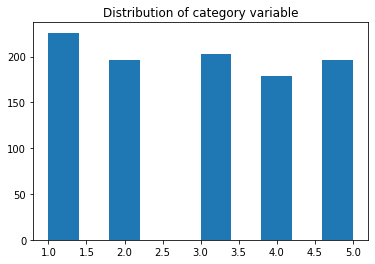

In [8]:
plt.hist(df['Stars'])
plt.title('Distribution of category variable');

In [9]:
df.head()

,Unnamed: 0,Title,Category,Price,Price_After_Tax,Tax_amount,Avilability,Number_of_reviews,Book_Description,Image_Link,Stars
0,0,A Light in the Attic,Poetry,51.77,51.77,0.0,22,0,It's hard to imagine a world without A Light i...,http://books.toscrape.com/media/cache/fe/72/fe...,3
1,1,Tipping the Velvet,Historical Fiction,53.74,53.74,0.0,20,0,"""Erotic and absorbing...Written with starling ...",http://books.toscrape.com/media/cache/08/e9/08...,1
2,2,Soumission,Fiction,50.10,50.10,0.0,20,0,"Dans une France assez proche de la nÃ´tre, un ...",http://books.toscrape.com/media/cache/ee/cf/ee...,1
3,3,Sharp Objects,Mystery,47.82,47.82,0.0,20,0,"WICKED above her hipbone, GIRL across her hear...",http://books.toscrape.com/media/cache/c0/59/c0...,4
4,4,Sapiens: A Brief History of Humankind,History,54.23,54.23,0.0,20,0,From a renowned historian comes a groundbreaki...,http://books.toscrape.com/media/cache/ce/5f/ce...,5


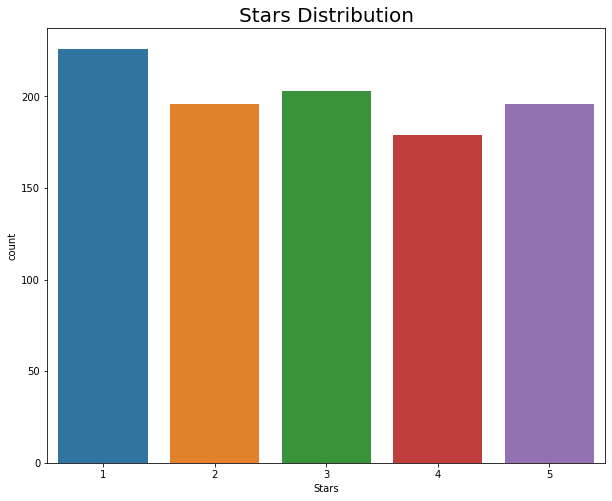

In [10]:
plt.figure(figsize=(10,8))
sns.countplot(x='Stars',data=df)
plt.title('Stars Distribution',size=20)
plt.show()

In [11]:
df["Stars"].value_counts(ascending=False)

1    226
3    203
5    196
2    196
4    179
Name: Stars, dtype: int64

c:\Users\nuvolaofficial\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


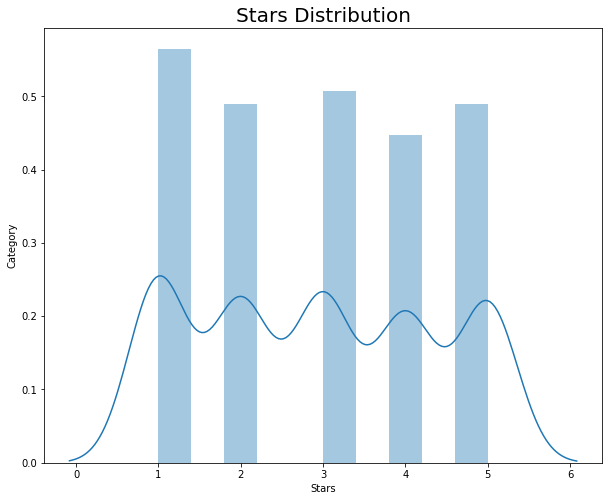

In [12]:
plt.figure(figsize=(10,8))
sns.distplot(df['Stars'],kde=True)
plt.xlabel('Stars')
plt.ylabel('Category')
plt.title('Stars Distribution',size=20)
plt.show()

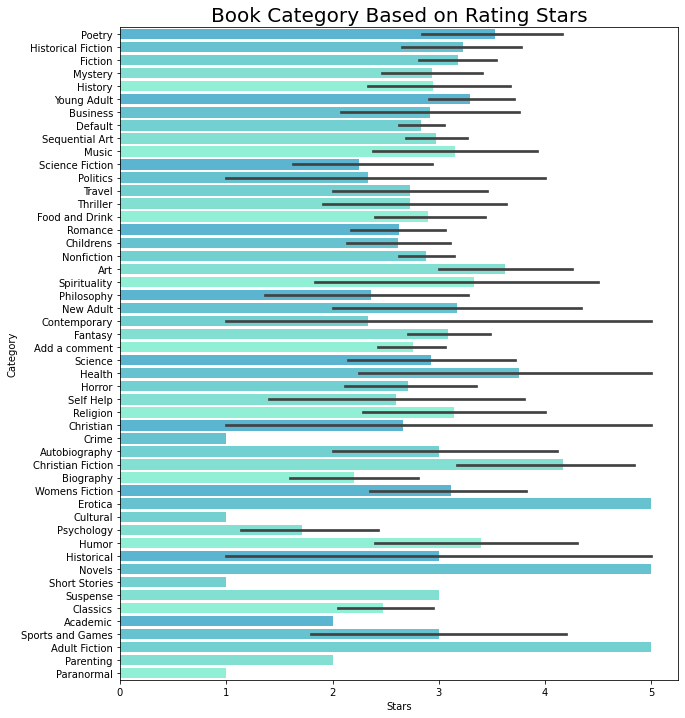

In [13]:
custom_colors = ['#48bfe3','#56cfe1','#64dfdf','#72efdd','#80ffdb']
customPalette = sns.color_palette(custom_colors)
def barplot(df,col,l):
    df_v=df[col].value_counts(any).head().reset_index()
    df_v.columns=[col,'Category']

    plt.figure(figsize=(10,12))
    sns.barplot(x='Stars',y=col,data=df,palette=customPalette)
    plt.ylabel("Category")
    plt.title("Book Category Based on Rating Stars",size=20)
    plt.show()
barplot(df,'Category','Stars')

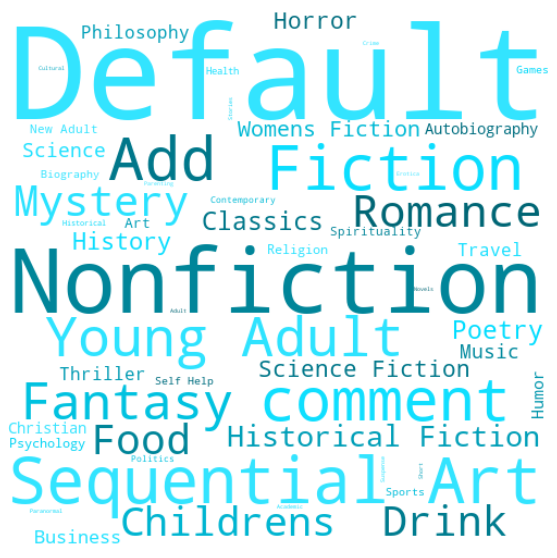

In [14]:
def color_func(word=None, font_size=None, position=None,  orientation=None, font_path=None, random_state=None):
    h = int(188)
    s = int(100.0 * 255 / 255.0)
    l = int(100.0 * float(random_state.randint(60, 160)) / 255.0)

    return "hsl({}, {}%, {}%)".format(h, s, l)
plt.subplots(figsize=(10,10))
wc = WordCloud(background_color="white", max_words=100,
               stopwords=STOPWORDS, max_font_size=256,
               random_state=42, width=500, height=500,color_func=color_func)
wc.generate(' '.join(df['Category']))
plt.imshow(wc, interpolation="bilinear")
plt.axis('off')
plt.show()

In [16]:
df.head()

,Unnamed: 0,Title,Category,Price,Price_After_Tax,Tax_amount,Avilability,Number_of_reviews,Book_Description,Image_Link,Stars
0,0,A Light in the Attic,Poetry,51.77,51.77,0.0,22,0,It's hard to imagine a world without A Light i...,http://books.toscrape.com/media/cache/fe/72/fe...,3
1,1,Tipping the Velvet,Historical Fiction,53.74,53.74,0.0,20,0,"""Erotic and absorbing...Written with starling ...",http://books.toscrape.com/media/cache/08/e9/08...,1
2,2,Soumission,Fiction,50.10,50.10,0.0,20,0,"Dans une France assez proche de la nÃ´tre, un ...",http://books.toscrape.com/media/cache/ee/cf/ee...,1
3,3,Sharp Objects,Mystery,47.82,47.82,0.0,20,0,"WICKED above her hipbone, GIRL across her hear...",http://books.toscrape.com/media/cache/c0/59/c0...,4
4,4,Sapiens: A Brief History of Humankind,History,54.23,54.23,0.0,20,0,From a renowned historian comes a groundbreaki...,http://books.toscrape.com/media/cache/ce/5f/ce...,5


c:\Users\nuvolaofficial\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Avilability', ylabel='Density'>

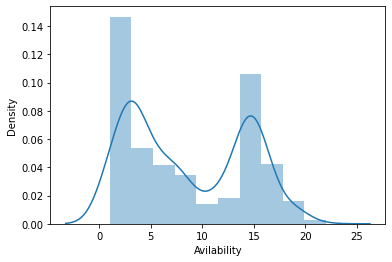

In [18]:
sns.distplot(df["Avilability"])

In [19]:
print("Skewness: %f" % df['Avilability'].skew())
print("Kurtosis: %f" % df['Avilability'].kurt())

Skewness: 0.212152
Kurtosis: -1.449876


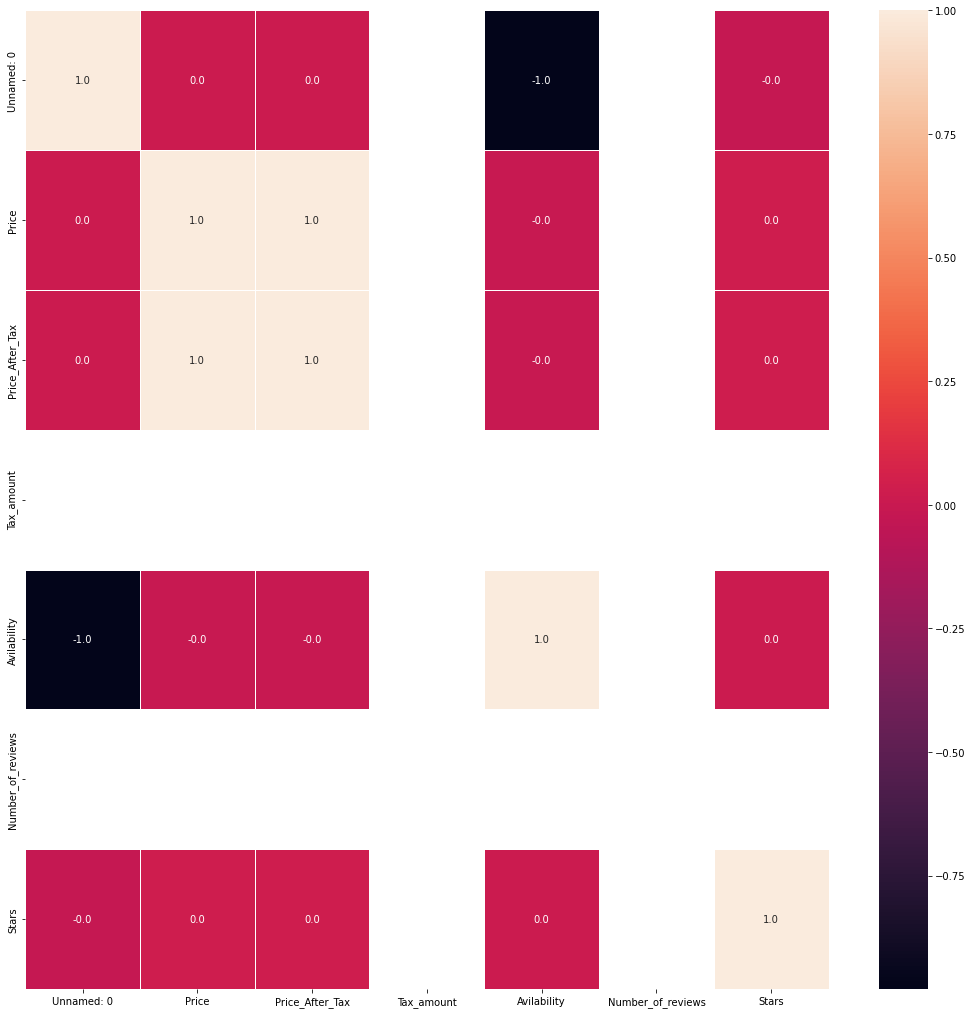

In [34]:
f,ax = plt.subplots(figsize=(18, 18))
sns.heatmap(df.corr(), annot=True, linewidths=.5, fmt= '.1f',ax=ax)
plt.show()